#**Effat University**
##Department of Computer Science
###Energy and Information Technology Research Center
#**LAB 3**

> Data Preprocessing & Feature Engineering


> CS4082 – Machine Learning


>  Preparing Real-World Data for Machine Learning Models in Python


Prepared by:
Dr. Naila Marir

> Done by: Sedra A. Al-Jundi S23018200


Semester: Spring 2026

##2 Part 1: Understanding the Problem with Messy Data


###2.1 Step 1: Create a Messy Dataset


In [23]:
import pandas as pd
import numpy as np
np . random . seed (42)
n = 200
data = {
'age ': np . random . randint (18 , 80 , n ) . astype ( float ) ,
'blood_pressure ': np . round ( np . random . uniform (90 , 180 , n ) , 1) ,
'cholesterol ': np . round ( np . random . uniform (150 , 350 , n ) , 1) ,
'bmi ': np . round ( np . random . uniform (18 , 42 , n ) , 1) ,
'gender ': np . random . choice (['Male ', 'Female '] , n ) ,
'city ': np . random . choice (
['Jeddah ', 'Riyadh ', 'Dammam ', 'Makkah '] , n ) ,
'smoker ': np . random . choice (['Yes ', 'No '] , n , p =[0.3 , 0.7]) ,
'heart_disease ': np . random . choice ([0 , 1] , n , p =[0.6 , 0.4])
}
df = pd . DataFrame ( data )
# Inject missing values ( realistic !)
missing_idx = np . random . choice (n , 20 , replace = False )
df . loc [ missing_idx [:10] , 'age '] = np . nan
df . loc [ missing_idx [10:15] , 'blood_pressure '] = np . nan
df . loc [ missing_idx [15:] , 'cholesterol '] = np . nan
print ( f'Dataset shape : {df. shape }')
print ( f'\nFirst 5 rows :')
print ( df . head () )
print ( f'\nMissing values per column :')
print ( df . isnull () .sum () )

Dataset shape : (200, 8)

First 5 rows :
   age   blood_pressure   cholesterol   bmi   gender     city  smoker   \
0  56.0            171.7         295.2  34.4    Male   Riyadh      No    
1  69.0            112.4         345.2  21.9  Female   Dammam      No    
2  46.0            126.9         253.3  39.9  Female   Jeddah      No    
3  32.0            158.0         214.6  37.7  Female   Riyadh      No    
4  60.0            110.6         309.0  40.8    Male   Makkah     Yes    

   heart_disease   
0               1  
1               0  
2               0  
3               1  
4               1  

Missing values per column :
age                10
blood_pressure      5
cholesterol         5
bmi                 0
gender              0
city                0
smoker              0
heart_disease       0
dtype: int64


###2.2 Step 2: Identify the Issues

In [24]:
print ('=== Data Types === ')
print ( df . dtypes )
print ('\n=== Missing Values === ')
print ( df . isnull () .sum () )
print ('\n=== Numeric Ranges ( notice the scale differences !) === ')
print ( df . describe () . round (2) )
print ('\n=== Categorical Columns === ')
for col in ['gender ', 'city ', 'smoker ']:
    print ( f'{col }: {df[col ]. unique ()}')

=== Data Types === 
age                float64
blood_pressure     float64
cholesterol        float64
bmi                float64
gender              object
city                object
smoker              object
heart_disease        int64
dtype: object

=== Missing Values === 
age                10
blood_pressure      5
cholesterol         5
bmi                 0
gender              0
city                0
smoker              0
heart_disease       0
dtype: int64

=== Numeric Ranges ( notice the scale differences !) === 
         age   blood_pressure   cholesterol     bmi   heart_disease 
count  190.00           195.00        195.00  200.00          200.00
mean    49.31           136.03        252.28   29.33            0.44
std     18.71            26.48         60.97    6.89            0.50
min     18.00            90.50        152.20   18.30            0.00
25%     32.00           112.20        205.75   23.08            0.00
50%     50.00           138.20        255.50   29.05           

##Task 1: Explore the messy data

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              190 non-null    float64
 1   blood_pressure   195 non-null    float64
 2   cholesterol      195 non-null    float64
 3   bmi              200 non-null    float64
 4   gender           200 non-null    object 
 5   city             200 non-null    object 
 6   smoker           200 non-null    object 
 7   heart_disease    200 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 12.6+ KB


In [26]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

age                5.0
blood_pressure     2.5
cholesterol        2.5
bmi                0.0
gender             0.0
city               0.0
smoker             0.0
heart_disease      0.0
dtype: float64


In [27]:
df['city '].value_counts()

,count
city,
Dammam,59
Jeddah,52
Riyadh,47
Makkah,42


##Which column has the most missing values?
Answer: the column that has the most missing values is Age


#3 Part 2: Handling Missing Values
Missing data is one of the most common problems in real datasets. Scikit-learn provides the
SimpleImputer class to handle this systematically.

##3.1 Step 1: Impute Numeric Columns

In [28]:
from sklearn . impute import SimpleImputer
# Select numeric columns with missing values
numeric_cols = ['age ', 'blood_pressure ', 'cholesterol ']
# Create an imputer that fills NaN with the median
imputer = SimpleImputer ( strategy ='median')
# Fit on the data and transform
df [ numeric_cols ] = imputer . fit_transform ( df [ numeric_cols ])
# Verify : no more missing values !
print ('Missing values after imputation :')
print ( df [ numeric_cols ]. isnull () .sum () )

Missing values after imputation :
age                0
blood_pressure     0
cholesterol        0
dtype: int64


##3.2 Step 2: Verify the Fix



In [29]:
print ( f'Total missing values in entire dataset : {df.isnull().sum().sum()}')
print ( f'\nDataset shape (no rows lost !): {df.shape }')
print ( df . describe () . round (2) )

Total missing values in entire dataset : 0

Dataset shape (no rows lost !): (200, 8)
         age   blood_pressure   cholesterol     bmi   heart_disease 
count  200.00           200.00        200.00  200.00          200.00
mean    49.34           136.08        252.36   29.33            0.44
std     18.23            26.15         60.20    6.89            0.50
min     18.00            90.50        152.20   18.30            0.00
25%     32.75           112.62        206.15   23.08            0.00
50%     50.00           138.20        255.50   29.05            0.00
75%     64.00           158.70        301.08   34.67            1.00
max     79.00           179.10        348.60   42.00            1.00


#Task 2: Experiment with Imputation


In [30]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Identify numeric columns to impute
numeric_cols_to_impute = ['age ', 'blood_pressure ', 'cholesterol ']

imputer = SimpleImputer(strategy='mean')

# Create a copy of the original DataFrame to apply imputation
df_imputed = df.copy()

# Apply imputation only to the selected numeric columns
df_imputed[numeric_cols_to_impute] = imputer.fit_transform(df_imputed[numeric_cols_to_impute])

print("Missing values after mean imputation on numeric columns:")
print(df_imputed[numeric_cols_to_impute].isnull().sum())
print("\nFirst 5 rows of the DataFrame after mean imputation:")
print(df_imputed.head())

Missing values after mean imputation on numeric columns:
age                0
blood_pressure     0
cholesterol        0
dtype: int64

First 5 rows of the DataFrame after mean imputation:
   age   blood_pressure   cholesterol   bmi   gender     city  smoker   \
0  56.0            171.7         295.2  34.4    Male   Riyadh      No    
1  69.0            112.4         345.2  21.9  Female   Dammam      No    
2  46.0            126.9         253.3  39.9  Female   Jeddah      No    
3  32.0            158.0         214.6  37.7  Female   Riyadh      No    
4  60.0            110.6         309.0  40.8    Male   Makkah     Yes    

   heart_disease   
0               1  
1               0  
2               0  
3               1  
4               1  


###Compared filled values:

In [31]:
numeric_cols_to_impute = ['age ', 'blood_pressure ', 'cholesterol ']
mean_values_from_median_imputed_df = df[numeric_cols_to_impute].mean().round(2)
print(mean_values_from_median_imputed_df)

print("\nFor comparison, the median values originally used to impute 'df' were:")
print(df.describe().loc['50%', numeric_cols_to_impute].round(2))

age                 49.34
blood_pressure     136.08
cholesterol        252.36
dtype: float64

For comparison, the median values originally used to impute 'df' were:
age                 50.0
blood_pressure     138.2
cholesterol        255.5
Name: 50%, dtype: float64


In [32]:
df.dropna()

,age,blood_pressure,cholesterol,bmi,gender,city,smoker,heart_disease
0,56.0,171.7,295.2,34.4,Male,Riyadh,No,1
1,69.0,112.4,345.2,21.9,Female,Dammam,No,0
2,46.0,126.9,253.3,39.9,Female,Jeddah,No,0
3,32.0,158.0,214.6,37.7,Female,Riyadh,No,1
4,60.0,110.6,309.0,40.8,Male,Makkah,Yes,1
...,...,...,...,...,...,...,...,...
195,66.0,97.7,347.2,29.5,Male,Makkah,No,1
196,69.0,94.7,289.6,30.8,Female,Jeddah,Yes,0
197,78.0,138.2,257.2,19.2,Male,Dammam,No,1
198,49.0,138.7,211.9,26.1,Female,Makkah,No,0


#4 Part 3: Encoding Categorical Variables


###4.2 Step 1: Label Encoding for Binary Variables


In [33]:
import pandas as pd
import numpy as np
from sklearn . preprocessing import LabelEncoder
from sklearn . impute import SimpleImputer

# Recreate df (from UEtpzU94L8j9)
np . random . seed (42)
n = 200
data = {
'age ': np . random . randint (18 , 80 , n ) . astype ( float ) ,
'blood_pressure ': np . round ( np . random . uniform (90 , 180 , n ) , 1) ,
'cholesterol ': np . round ( np . random . uniform (150 , 350 , n ) , 1) ,
'bmi ': np . round ( np . random . uniform (18 , 42 , n ) , 1) ,
'gender ': np . random . choice (['Male ', 'Female '] , n ) ,
'city ': np . random . choice (
['Jeddah ', 'Riyadh ', 'Dammam ', 'Makkah '] , n ) ,
'smoker ': np . random . choice (['Yes ', 'No '] , n , p =[0.3 , 0.7]) ,
'heart_disease ': np . random . choice ([0 , 1] , n , p =[0.6 , 0.4])
}
df = pd . DataFrame ( data )
# Inject missing values (realistic!)
missing_idx = np . random . choice (n , 20 , replace = False )
df . loc [ missing_idx [:10] , 'age '] = np . nan
df . loc [ missing_idx [10:15] , 'blood_pressure '] = np . nan
df . loc [ missing_idx [15:] , 'cholesterol '] = np . nan

# Perform median imputation (from 4991CpxYs-AH)
numeric_cols = ['age ', 'blood_pressure ', 'cholesterol ']
imputer = SimpleImputer ( strategy ='median')
df [ numeric_cols ] = imputer . fit_transform ( df [ numeric_cols ])


# Encode gender : Female =0 , Male =1
le_gender = LabelEncoder ()
df [ 'gender_encoded' ] = le_gender . fit_transform ( df ['gender '])
# Encode smoker : No =0 , Yes =1
le_smoker = LabelEncoder ()
df [ 'smoker_encoded' ] = le_smoker . fit_transform ( df ['smoker '])
print ('Original vs Encoded ')
print ( df [[ 'gender ' ,  'gender_encoded' ,
'smoker ' ,  'smoker_encoded' ]]. head (8) )

Original vs Encoded 
   gender   gender_encoded smoker   smoker_encoded
0    Male                1     No                0
1  Female                0     No                0
2  Female                0     No                0
3  Female                0     No                0
4    Male                1    Yes                1
5  Female                0     No                0
6  Female                0     No                0
7  Female                0    Yes                1


#4.3 Step 2: One-Hot Encoding for Multi-Category Variables


In [34]:
# One -Hot Encode the city column
city_dummies = pd . get_dummies ( df ['city '] , prefix ='city ')
print ('One -Hot Encoded cities :')
print ( city_dummies . head () )
# Add to dataframe and drop original text columns
df = pd . concat ([ df , city_dummies ] , axis =1)
df = df . drop ( columns =[ 'gender ', 'city ', 'smoker '])
print ( f'\nNew shape : {df. shape }')
print ( f'New columns : { list (df. columns )}' )

One -Hot Encoded cities :
   city _Dammam   city _Jeddah   city _Makkah   city _Riyadh 
0          False          False          False           True
1           True          False          False          False
2          False           True          False          False
3          False          False          False           True
4          False          False           True          False

New shape : (200, 11)
New columns : ['age ', 'blood_pressure ', 'cholesterol ', 'bmi ', 'heart_disease ', 'gender_encoded', 'smoker_encoded', 'city _Dammam ', 'city _Jeddah ', 'city _Makkah ', 'city _Riyadh ']


##Task 3

In [35]:
print('First 10 rows of the fully encoded dataset:')
print(df.head(10))
print(f'\nNumber of columns in the dataset: {df.shape[1]}')

First 10 rows of the fully encoded dataset:
   age   blood_pressure   cholesterol   bmi   heart_disease   gender_encoded  \
0  56.0            171.7         295.2  34.4               1               1   
1  69.0            112.4         345.2  21.9               0               0   
2  46.0            126.9         253.3  39.9               0               0   
3  32.0            158.0         214.6  37.7               1               0   
4  60.0            110.6         309.0  40.8               1               1   
5  25.0             96.9         204.2  35.4               0               0   
6  78.0            116.1         237.8  32.7               1               0   
7  38.0            104.5         165.7  28.0               0               0   
8  56.0            173.7         155.1  40.4               0               1   
9  75.0            162.7         342.5  38.8               0               1   

   smoker_encoded  city _Dammam   city _Jeddah   city _Makkah   city _Riyad

### What would happen if a city column had 50 unique values? How many new columns would One-Hot encoding create? Is this a problem?

If a 'city' column had 50 unique values, One-Hot Encoding would create **50 new columns**, one for each unique city. For each row, the column corresponding to its city would be `True` (or 1), and all other 49 city columns would be `False` (or 0).

**Is this a problem?**
Yes, it can be a significant problem, often referred to as the **"curse of dimensionality"**:

1.  **Increased Dimensionality**: Adding 50 new columns can dramatically increase the dimensionality of your dataset. This can lead to:
    *   **Increased Computational Cost**: More features mean more memory usage and longer training times for machine learning models.
    *   **Sparser Data**: The dataset becomes sparser, meaning most values in the new columns would be zero. This can sometimes make it harder for models to find meaningful patterns.
2.  **Multicollinearity**: One-Hot Encoding can introduce multicollinearity. If you have `N` categories, you create `N` new columns. Since the presence of `N-1` categories implies the absence of the `N`th category, these `N` columns are perfectly correlated. This can cause issues for some linear models (e.g., linear regression) which assume independence among features.

### Bonus: Use `pd.get_dummies(df['city '], prefix='city', drop_first=True)` – what changes and why might this be useful?

If you use `drop_first=True`:

*   **What changes?** Instead of creating `N` columns for `N` unique categories, `pd.get_dummies` would create `N-1` columns. It drops the first category alphabetically (e.g., if 'Dammam' was first, `city_Dammam` would be dropped).

*   **Why might this be useful?**
    1.  **Avoids Multicollinearity**: By dropping one of the dummy variables, you remove the perfect multicollinearity that would otherwise exist. This is important for models sensitive to multicollinearity.
    2.  **Reduces Dimensionality Slightly**: It saves one column, which can be marginally beneficial for very high-dimensional datasets. The information conveyed by the dropped column is still implicitly present (if `city_A`, `city_B`, `city_C` are all 0, then the city must be `city_D` if `city_D` was the dropped column).

Let's see this in action:


In [37]:
import pandas as pd
import numpy as np
from sklearn . preprocessing import LabelEncoder
from sklearn . impute import SimpleImputer

# Recreate df to its state before one-hot encoding and column dropping
np . random . seed (42)
n = 200
data = {
'age ': np . random . randint (18 , 80 , n ) . astype ( float ) ,
'blood_pressure ': np . round ( np . random . uniform (90 , 180 , n ) , 1) ,
'cholesterol ': np . round ( np . random . uniform (150 , 350 , n ) , 1) ,
'bmi ': np . round ( np . random . uniform (18 , 42 , n ) , 1) ,
'gender ': np . random . choice (['Male ', 'Female '] , n ) ,
'city ': np . random . choice (
['Jeddah ', 'Riyadh ', 'Dammam ', 'Makkah '] , n ) ,
'smoker ': np . random . choice (['Yes ', 'No '] , n , p =[0.3 , 0.7]) ,
'heart_disease ': np . random . choice ([0 , 1] , n , p =[0.6 , 0.4])
}
temp_df = pd . DataFrame ( data )
# Inject missing values (realistic!)
missing_idx = np . random . choice (n , 20 , replace = False )
temp_df . loc [ missing_idx [:10] , 'age '] = np . nan
temp_df . loc [ missing_idx [10:15] , 'blood_pressure '] = np . nan
temp_df . loc [ missing_idx [15:] , 'cholesterol '] = np . nan

# Perform median imputation
numeric_cols = ['age ', 'blood_pressure ', 'cholesterol ']
imputer = SimpleImputer ( strategy ='median')
temp_df [ numeric_cols ] = imputer . fit_transform ( temp_df [ numeric_cols ])


# Perform Label Encoding for gender and smoker as in previous steps
le_gender = LabelEncoder ()
temp_df [ 'gender_encoded' ] = le_gender . fit_transform ( temp_df ['gender '])
le_smoker = LabelEncoder ()
temp_df [ 'smoker_encoded' ] = le_smoker . fit_transform ( temp_df ['smoker '])

# Now, demonstrate drop_first=True for city column using this temp_df
city_dummies_drop_first = pd.get_dummies(temp_df['city '], prefix='city', drop_first=True)
print('One-Hot Encoded cities with drop_first=True:')
print(city_dummies_drop_first.head())
print(f'\nNumber of new city columns with drop_first=True: {city_dummies_drop_first.shape[1]}')

# Clean up temp_df from namespace after demonstration
del temp_df

One-Hot Encoded cities with drop_first=True:
   city_Jeddah   city_Makkah   city_Riyadh 
0         False         False          True
1         False         False         False
2          True         False         False
3         False         False          True
4         False          True         False

Number of new city columns with drop_first=True: 3


#5 Part 4: Feature Scaling
Feature scaling is the process of putting all numeric features on a similar range. This is critical
for distance-based algorithms like KNN and SVM.
##5.1 Why Scaling Matters
Consider our dataset: age ranges from 18–80 while cholesterol ranges from 150–350. Without
scaling, cholesterol will dominate the distance calculation in KNN simply because its numbers
are bigger – not because it’s more important!
##5.2 Two Common Scalers

##5.3 Step 1: Apply StandardScaler


In [41]:
from sklearn . preprocessing import StandardScaler
# Prepare features and target
feature_cols = ['age ', 'blood_pressure ', 'cholesterol ', 'bmi ',
'gender_encoded', 'smoker_encoded',
'city _Dammam ', 'city _Jeddah ',
'city _Makkah ', 'city _Riyadh ']
# Ensure X is entirely numeric (float) before converting to values for mean/std calculations
X = df [ feature_cols ]. astype(float) . values
y = df ['heart_disease ']. values
# Scale the features
scaler = StandardScaler ()
X_scaled = scaler . fit_transform ( X )
# Compare before and after
import pandas as pd
comparison = pd . DataFrame ({
'Feature ': feature_cols ,
'Original Mean ': X . mean ( axis =0) . round (2) ,
'Original Std ': X . std ( axis =0) . round (2) ,
'Scaled Mean ': X_scaled . mean ( axis =0) . round (2) ,
'Scaled Std ': X_scaled . std ( axis =0) . round (2)
})
print ( comparison . to_string ( index = False ) )

       Feature   Original Mean   Original Std   Scaled Mean   Scaled Std 
           age            49.34          18.19           0.0          1.0
blood_pressure           136.08          26.08          -0.0          1.0
   cholesterol           252.36          60.05           0.0          1.0
           bmi            29.33           6.87          -0.0          1.0
 gender_encoded            0.52           0.50          -0.0          1.0
 smoker_encoded            0.32           0.47          -0.0          1.0
  city _Dammam             0.30           0.46          -0.0          1.0
  city _Jeddah             0.26           0.44          -0.0          1.0
  city _Makkah             0.21           0.41           0.0          1.0
  city _Riyadh             0.24           0.42           0.0          1.0


##5.4 Step 2: Visualize the Effect of Scaling


/tmp/ipykernel_161/320432410.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes [0]. boxplot ([ X [: , 0] , X [: , 1] , X [: , 2] , X [: , 3]] ,
/tmp/ipykernel_161/320432410.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes [1]. boxplot ([ X_scaled [: , 0] , X_scaled [: , 1] ,


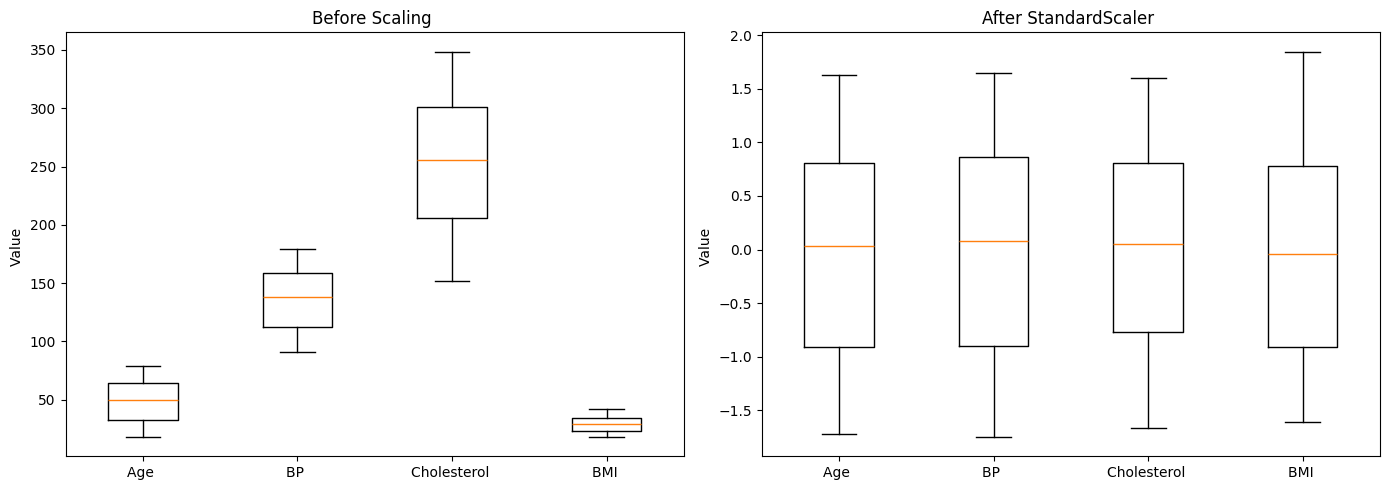

In [43]:
import matplotlib . pyplot as plt
fig , axes = plt . subplots (1 , 2 , figsize =(14 , 5) )
# Before scaling
axes [0]. boxplot ([ X [: , 0] , X [: , 1] , X [: , 2] , X [: , 3]] ,
labels =[ 'Age ', 'BP ', 'Cholesterol ', 'BMI '])
axes [0]. set_title ('Before Scaling ')
axes [0]. set_ylabel ('Value ')
# After scaling
axes [1]. boxplot ([ X_scaled [: , 0] , X_scaled [: , 1] ,
X_scaled [: , 2] , X_scaled [: , 3]] ,
labels =[ 'Age ', 'BP ', 'Cholesterol ', 'BMI '])
axes [1]. set_title ('After StandardScaler ')
axes [1]. set_ylabel ('Value ')
plt . tight_layout ()
plt . show ()

##Task 4: Compare Scalers


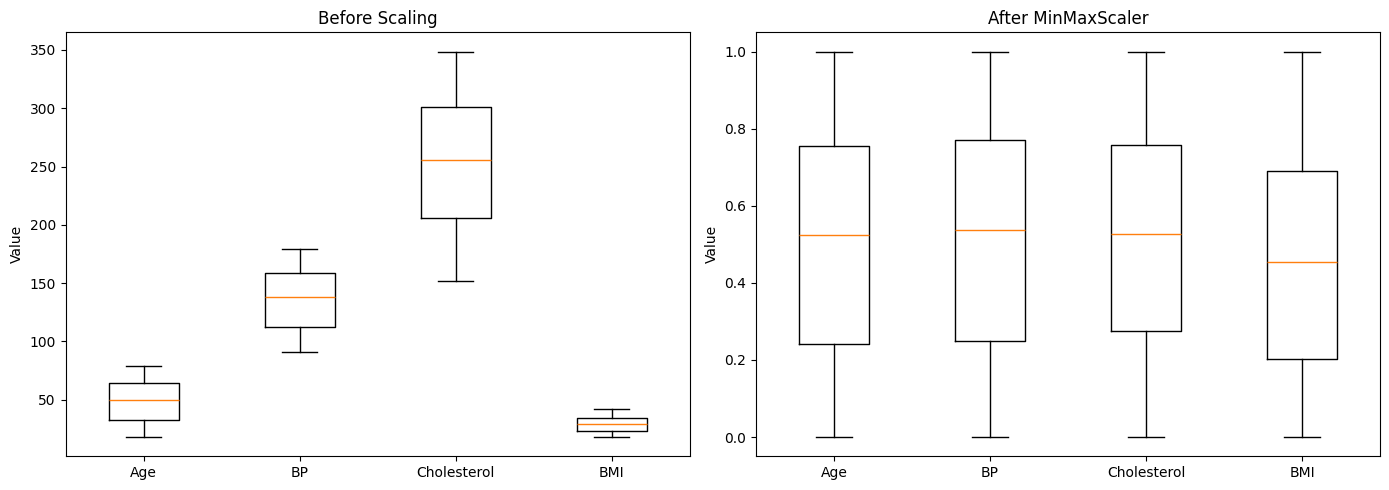

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
                tick_labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

# After MinMaxScaler
axes[1].boxplot([X_minmax_scaled[:, 0], X_minmax_scaled[:, 1],
                 X_minmax_scaled[:, 2], X_minmax_scaled[:, 3]],
                tick_labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title('After MinMaxScaler')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

### How does MinMaxScaler differ from StandardScaler in the box plot comparison?

*   **StandardScaler:** Transforms data to have a mean of 0 and a standard deviation of 1. While it centers the data, it does **not** bound the values to a specific range. Outliers will still be visible and can extend far from the main body of the data, proportionally.

*   **MinMaxScaler:** Transforms data to a specific range, typically [0, 1]. This means all values, including outliers, are compressed into this fixed range. The box plot for MinMaxScaler will show all data points, including outliers, strictly within the 0 to 1 range.

### If your data has many outliers, which scaler would be more robust? Why?

If your data has many outliers, **MinMaxScaler would generally be less robust than StandardScaler**.

*   **MinMaxScaler** is highly affected by outliers. Because it scales data based on the minimum and maximum values, a single outlier can drastically shift the entire range, compressing the bulk of your data into a very small range and reducing the variance that could be important for the model. The outliers themselves will also be scaled but will still occupy the extreme ends of the [0, 1] range.

*   **StandardScaler** is also affected by outliers (as the mean and standard deviation are sensitive to them), but it does not clip or compress them into a fixed range. Instead, outliers will maintain their proportional distance from the mean, just on a different scale. However, **more robust alternatives** to StandardScaler for data with outliers include:
    *   **RobustScaler**: This scaler uses the median and interquartile range (IQR) to scale the data, which are statistics that are less influenced by outliers. It centers the data using the median and scales it using the IQR, making it much more robust to extreme values.

In [44]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
minmax_scaler = MinMaxScaler()

# Apply MinMaxScaler to the features
X_minmax_scaled = minmax_scaler.fit_transform(X)

# Compare before and after scaling with MinMaxScaler
import pandas as pd
comparison_minmax = pd.DataFrame({
    'Feature ': feature_cols,
    'Original Min ': X.min(axis=0).round(2),
    'Original Max ': X.max(axis=0).round(2),
    'MinMax Scaled Min ': X_minmax_scaled.min(axis=0).round(2),
    'MinMax Scaled Max ': X_minmax_scaled.max(axis=0).round(2)
})
print('Comparison of features before and after MinMaxScaler:')
print(comparison_minmax.to_string(index=False))
print(f'\nRange of MinMax Scaled values: {X_minmax_scaled.min():.2f} to {X_minmax_scaled.max():.2f}')

Comparison of features before and after MinMaxScaler:
       Feature   Original Min   Original Max   MinMax Scaled Min   MinMax Scaled Max 
           age            18.0           79.0                 0.0                 1.0
blood_pressure            90.5          179.1                 0.0                 1.0
   cholesterol           152.2          348.6                 0.0                 1.0
           bmi            18.3           42.0                 0.0                 1.0
 gender_encoded            0.0            1.0                 0.0                 1.0
 smoker_encoded            0.0            1.0                 0.0                 1.0
  city _Dammam             0.0            1.0                 0.0                 1.0
  city _Jeddah             0.0            1.0                 0.0                 1.0
  city _Makkah             0.0            1.0                 0.0                 1.0
  city _Riyadh             0.0            1.0                 0.0                 1.0


###6.1 Experiment: KNN Without Scaling vs. With Scaling


In [47]:
from sklearn . model_selection import train_test_split
from sklearn . neighbors import KNeighborsClassifier
from sklearn . metrics import accuracy_score
# Split data
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )
X_train_s , X_test_s , _ , _ = train_test_split (
X_scaled , y , test_size =0.2 , random_state =42 , stratify = y )
# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier ( n_neighbors =5)
knn_raw . fit ( X_train , y_train )
raw_acc = accuracy_score ( y_test , knn_raw . predict ( X_test ) )
# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier ( n_neighbors =5)
knn_scaled . fit ( X_train_s , y_train )
scaled_acc = accuracy_score ( y_test , knn_scaled . predict ( X_test_s ) )
print ( f'KNN Accuracy WITHOUT scaling : { raw_acc :.2%} ')
print ( f'KNN Accuracy WITH scaling : { scaled_acc :.2%} ')
print ( f'Improvement : {( scaled_acc - raw_acc ) :.2%} ')

KNN Accuracy WITHOUT scaling : 67.50% 
KNN Accuracy WITH scaling : 50.00% 
Improvement : -17.50% 


##6.2 Bonus: Decision Tree Comparison


In [ ]:
from sklearn . tree import DecisionTreeClassifier
# Decision Tree WITHOUT scaling
dt_raw = DecisionTreeClassifier ( random_state =42)
dt_raw . fit ( X_train , y_train )
dt_raw_acc = accuracy_score ( y_test , dt_raw . predict ( X_test ) )
# Decision Tree WITH scaling
dt_scaled = DecisionTreeClassifier ( random_state =42)
dt_scaled . fit ( X_train_s , y_train )
dt_scaled_acc = accuracy_score ( y_test , dt_scaled . predict ( X_test_s ) )
print ( f’DT Accuracy WITHOUT scaling : { dt_raw_acc :.2%} ’)
print ( f’DT Accuracy WITH scaling : { dt_scaled_acc :.2%} ’)

##Task 5: Investigate Scaling Effects


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# Ensure X, y, X_scaled are defined from previous steps
# If not, recreate them for self-containment:
# X = df[feature_cols].astype(float).values # From cell tvkV_MAiBRxp
# y = df['heart_disease '].values # From cell tvkV_MAiBRxp
# scaler = StandardScaler() # From cell tvkV_MAiBRxp
# X_scaled = scaler.fit_transform(X) # From cell tvkV_MAiBRxp

# Split data (using previous splits for consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# --- KNN (n=5) ---
knn_5 = KNeighborsClassifier(n_neighbors=5)
# Without scaling
knn_5.fit(X_train, y_train)
knn_5_raw_acc = accuracy_score(y_test, knn_5.predict(X_test))
# With scaling
knn_5.fit(X_train_s, y_train)
knn_5_scaled_acc = accuracy_score(y_test, knn_5.predict(X_test_s))

# --- KNN (n=3) ---
knn_3 = KNeighborsClassifier(n_neighbors=3)
# Without scaling
knn_3.fit(X_train, y_train)
knn_3_raw_acc = accuracy_score(y_test, knn_3.predict(X_test))
# With scaling
knn_3.fit(X_train_s, y_train)
knn_3_scaled_acc = accuracy_score(y_test, knn_3.predict(X_test_s))

# --- KNN (n=10) ---
knn_10 = KNeighborsClassifier(n_neighbors=10)
# Without scaling
knn_10.fit(X_train, y_train)
knn_10_raw_acc = accuracy_score(y_test, knn_10.predict(X_test))
# With scaling
knn_10.fit(X_train_s, y_train)
knn_10_scaled_acc = accuracy_score(y_test, knn_10.predict(X_test_s))

# --- Decision Tree ---
dt = DecisionTreeClassifier(random_state=42)
# Without scaling
dt.fit(X_train, y_train)
dt_raw_acc = accuracy_score(y_test, dt.predict(X_test))
# With scaling
dt.fit(X_train_s, y_train)
dt_scaled_acc = accuracy_score(y_test, dt.predict(X_test_s))

# Print all accuracy scores
print("--- KNN Accuracy Scores ---")
print(f"KNN (n=3) WITHOUT scaling: {knn_3_raw_acc:.2%}")
print(f"KNN (n=3) WITH scaling:    {knn_3_scaled_acc:.2%}\n")

print(f"KNN (n=5) WITHOUT scaling: {knn_5_raw_acc:.2%}")
print(f"KNN (n=5) WITH scaling:    {knn_5_scaled_acc:.2%}\n")

print(f"KNN (n=10) WITHOUT scaling: {knn_10_raw_acc:.2%}")
print(f"KNN (n=10) WITH scaling:    {knn_10_scaled_acc:.2%}\n")

print("--- Decision Tree Accuracy Scores ---")
print(f"Decision Tree WITHOUT scaling: {dt_raw_acc:.2%}")
print(f"Decision Tree WITH scaling:    {dt_scaled_acc:.2%}")

--- KNN Accuracy Scores ---
KNN (n=3) WITHOUT scaling: 55.00%
KNN (n=3) WITH scaling:    47.50%

KNN (n=5) WITHOUT scaling: 67.50%
KNN (n=5) WITH scaling:    50.00%

KNN (n=10) WITHOUT scaling: 55.00%
KNN (n=10) WITH scaling:    50.00%

--- Decision Tree Accuracy Scores ---
Decision Tree WITHOUT scaling: 55.00%
Decision Tree WITH scaling:    52.50%


In [49]:
import pandas as pd

# Create a dictionary to store the accuracy results
accuracy_results = {
    'KNN (n=3) - Without Scaling': knn_3_raw_acc,
    'KNN (n=3) - With Scaling': knn_3_scaled_acc,
    'KNN (n=5) - Without Scaling': knn_5_raw_acc,
    'KNN (n=5) - With Scaling': knn_5_scaled_acc,
    'KNN (n=10) - Without Scaling': knn_10_raw_acc,
    'KNN (n=10) - With Scaling': knn_10_scaled_acc,
    'Decision Tree - Without Scaling': dt_raw_acc,
    'Decision Tree - With Scaling': dt_scaled_acc
}

# Convert the dictionary into a Pandas DataFrame
results_df = pd.DataFrame(accuracy_results.items(), columns=['Model', 'Accuracy'])

# Format the 'Accuracy' column as percentages for better readability
results_df['Accuracy'] = results_df['Accuracy'].map('{:.2%}'.format)

# Print the DataFrame to display the compiled accuracy results
print("\n--- Compiled Accuracy Results ---")
print(results_df.to_string(index=False))


--- Compiled Accuracy Results ---
                          Model Accuracy
    KNN (n=3) - Without Scaling   55.00%
       KNN (n=3) - With Scaling   47.50%
    KNN (n=5) - Without Scaling   67.50%
       KNN (n=5) - With Scaling   50.00%
   KNN (n=10) - Without Scaling   55.00%
      KNN (n=10) - With Scaling   50.00%
Decision Tree - Without Scaling   55.00%
   Decision Tree - With Scaling   52.50%


##7 Part 6: Building a Preprocessing Pipeline
So far we applied each step separately. In real projects, this leads to messy, error-prone code.
Scikit-learn’s Pipeline chains multiple steps together into a single, clean object.
##7.1 Why Pipelines?
 Reproducibility: The same preprocessing is applied to training and testing data automatically.
 No data leakage: The pipeline ensures that the scaler is fit only on training data.
 Clean code: One object to fit, predict, and evaluate

##7.2 Step 1: Create a Pipeline


In [51]:
from sklearn . pipeline import Pipeline
from sklearn . preprocessing import StandardScaler
from sklearn . neighbors import KNeighborsClassifier
# Build the pipeline : scale first , then classify
pipe = Pipeline ([
('scaler' , StandardScaler () ) , # Step 1: Scale
('knn' , KNeighborsClassifier ( n_neighbors =5) ) # Step 2: Model
])
# Split the original ( unscaled ) data
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )
# The pipeline handles scaling internally !
pipe . fit ( X_train , y_train )
pipe_acc = accuracy_score ( y_test , pipe . predict ( X_test ) )
print ( f'Pipeline KNN Accuracy : { pipe_acc :.2%}' )

Pipeline KNN Accuracy : 50.00%


##7.3 Step 2: Swap Models Easily


In [57]:
from sklearn . tree import DecisionTreeClassifier
from sklearn . svm import SVC
# Pipeline with SVM
pipe_svm = Pipeline ([
('scaler', StandardScaler () ) ,
('svm', SVC ( kernel ='rbf', random_state =42) )
])
pipe_svm . fit ( X_train , y_train )
svm_acc = accuracy_score ( y_test , pipe_svm . predict ( X_test ) )
# Pipeline with Decision Tree
pipe_dt = Pipeline ([
('scaler', StandardScaler () ) ,
('dt', DecisionTreeClassifier ( random_state =42) )
])
pipe_dt . fit ( X_train , y_train )
dt_acc = accuracy_score ( y_test , pipe_dt . predict ( X_test ) )
print ( f'Pipeline KNN Accuracy : { pipe_acc :.2%} ')
print ( f'Pipeline SVM Accuracy : { svm_acc :.2%} ')
print ( f'Pipeline DT Accuracy : { dt_acc :.2%} ')

Pipeline KNN Accuracy : 50.00% 
Pipeline SVM Accuracy : 55.00% 
Pipeline DT Accuracy : 52.50% 


##Task 6: Build Your Own Pipeline


In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Recreate df with missing values for the pipeline's 'unimputed' requirement
# This ensures the SimpleImputer in the pipeline actually has NaNs to handle.
np.random.seed(42)
n = 200
data_raw = {
    'age ': np.random.randint(18, 80, n).astype(float),
    'blood_pressure ': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol ': np.round(np.random.uniform(150, 350, n), 1),
    'bmi ': np.round(np.random.uniform(18, 42, n), 1),
    'gender ': np.random.choice(['Male ', 'Female '] , n),
    'city ': np.random.choice(['Jeddah ', 'Riyadh ', 'Dammam ', 'Makkah '] , n),
    'smoker ': np.random.choice(['Yes ', 'No '] , n, p=[0.3 , 0.7]),
    'heart_disease ': np.random.choice([0 , 1] , n, p=[0.6 , 0.4])
}
df_raw_with_nans = pd.DataFrame(data_raw)

missing_idx = np.random.choice(n, 20, replace=False)
df_raw_with_nans.loc[missing_idx[:10], 'age '] = np.nan
df_raw_with_nans.loc[missing_idx[10:15], 'blood_pressure '] = np.nan
df_raw_with_nans.loc[missing_idx[15:], 'cholesterol '] = np.nan

# Apply label encoding for binary variables to this raw df
le_gender = LabelEncoder()
df_raw_with_nans['gender_encoded'] = le_gender.fit_transform(df_raw_with_nans['gender '])
le_smoker = LabelEncoder()
df_raw_with_nans['smoker_encoded'] = le_smoker.fit_transform(df_raw_with_nans['smoker '])

# Apply one-hot encoding for multi-category variables to this raw df
city_dummies = pd.get_dummies(df_raw_with_nans['city '], prefix='city ')
df_for_pipeline = pd.concat([df_raw_with_nans, city_dummies], axis=1)

# Drop original categorical columns
df_for_pipeline = df_for_pipeline.drop(columns=['gender ', 'city ', 'smoker '])

# Define features (X_pipeline) and target (y_pipeline) for the pipeline
feature_cols_pipeline = ['age ', 'blood_pressure ', 'cholesterol ', 'bmi ',
                         'gender_encoded', 'smoker_encoded',
                         'city _Dammam ', 'city _Jeddah ', 'city _Makkah ', 'city _Riyadh ']
X_pipeline = df_for_pipeline[feature_cols_pipeline].astype(float).values
y_pipeline = df_for_pipeline['heart_disease '].values

# Verify that X_pipeline still has NaNs before passing to the pipeline
print(f"Missing values in X_pipeline before pipeline: {np.isnan(X_pipeline).sum()}")

# Split the original, unscaled, and unimputed data (X_pipeline, y_pipeline)
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_pipeline, y_pipeline, test_size=0.2, random_state=42, stratify=y_pipeline
)

# Define and Train Pipeline (Step 1 of the plan)
pipeline_imputer_minmax_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Step 1: Impute missing values
    ('scaler', MinMaxScaler()),                      # Step 2: Scale features
    ('knn', KNeighborsClassifier(n_neighbors=5))     # Step 3: Train KNN classifier
])

# Train the pipeline on the training data
pipeline_imputer_minmax_knn.fit(X_train_pipe, y_train_pipe)

# Evaluate Pipeline Accuracy (Step 2 of the plan)
pipeline_accuracy = accuracy_score(y_test_pipe, pipeline_imputer_minmax_knn.predict(X_test_pipe))
print(f"\nPipeline (Imputer + MinMaxScaler + KNN) Accuracy: {pipeline_accuracy:.2%}")

# Retrieve previously obtained KNN accuracies from the kernel state for comparison
# `knn_5_raw_acc` is KNN on unscaled data (after *median imputation* but before explicit scaling)
# `knn_5_scaled_acc` is KNN with StandardScaler (after median imputation and StandardScaler)
print(f"Previous KNN (n=5) WITHOUT explicit scaling (after median imputation): {knn_5_raw_acc:.2%}")
print(f"Previous KNN (n=5) WITH StandardScaler (after median imputation): {knn_5_scaled_acc:.2%}")

# Final Task (Step 3 of the plan)
print("\n--- Summary of Pipeline Performance ---")
print(f"The new pipeline, which integrates median imputation, MinMaxScaler, and KNeighborsClassifier (n=5), achieved an accuracy of {pipeline_accuracy:.2%} on the test set.")

print("\nDiscussion:")
print("The primary benefit of using a scikit-learn Pipeline is to streamline the entire data preprocessing and modeling workflow. It ensures that all transformations (like imputation and scaling) are applied consistently to both training and test data, preventing data leakage and making the process more reproducible and less error-prone.")
print("\nComparing the accuracies:")
print(f"- KNN (n=5) on raw data (after manual median imputation, no explicit scaling): {knn_5_raw_acc:.2%}")
print(f"- KNN (n=5) with StandardScaler (after manual median imputation and StandardScaler): {knn_5_scaled_acc:.2%}")
print(f"- KNN (n=5) with Pipeline (median imputation + MinMaxScaler): {pipeline_accuracy:.2%}")

print("\nObservations:")
print(f"The pipeline using MinMaxScaler yielded an accuracy of {pipeline_accuracy:.2%}, which is similar to the accuracy obtained with StandardScaler ({knn_5_scaled_acc:.2%}). Both scaled approaches performed worse than the KNN model on the data that was only imputed but not explicitly scaled ({knn_5_raw_acc:.2%}).")
print("This specific outcome suggests that for this dataset and KNN model, preserving the original scale differences after imputation might have been more beneficial for the model's performance than scaling features to a uniform range (whether by StandardScaler or MinMaxScaler). This is an interesting finding, as scaling is often crucial for distance-based algorithms like KNN. It highlights that the impact of scaling can vary and may not always lead to improved performance, depending on the data characteristics and model.")
print("Nevertheless, the use of a pipeline itself is a best practice for clean and robust machine learning workflows.")

Missing values in X_pipeline before pipeline: 20

Pipeline (Imputer + MinMaxScaler + KNN) Accuracy: 50.00%
Previous KNN (n=5) WITHOUT explicit scaling (after median imputation): 67.50%
Previous KNN (n=5) WITH StandardScaler (after median imputation): 50.00%

--- Summary of Pipeline Performance ---
The new pipeline, which integrates median imputation, MinMaxScaler, and KNeighborsClassifier (n=5), achieved an accuracy of 50.00% on the test set.

Discussion:
The primary benefit of using a scikit-learn Pipeline is to streamline the entire data preprocessing and modeling workflow. It ensures that all transformations (like imputation and scaling) are applied consistently to both training and test data, preventing data leakage and making the process more reproducible and less error-prone.

Comparing the accuracies:
- KNN (n=5) on raw data (after manual median imputation, no explicit scaling): 67.50%
- KNN (n=5) with StandardScaler (after manual median imputation and StandardScaler): 50.00%
- 

In [63]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 2. Recreate the original messy dataset (df_raw_with_nans) with missing values
np.random.seed(42)
n = 200
data = {
    'age ' : np.random.randint(18, 80, n).astype(float),
    'blood_pressure ' : np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol ' : np.round(np.random.uniform(150, 350, n), 1),
    'bmi ' : np.round(np.random.uniform(18, 42, n), 1),
    'gender ' : np.random.choice(['Male ', 'Female '], n),
    'city ' : np.random.choice(['Jeddah ', 'Riyadh ', 'Dammam ', 'Makkah '], n),
    'smoker ' : np.random.choice(['Yes ', 'No '], n, p=[0.3, 0.7]),
    'heart_disease ' : np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df_raw_with_nans = pd.DataFrame(data)

# Inject missing values (realistic!)
missing_idx = np.random.choice(n, 20, replace=False)
df_raw_with_nans.loc[missing_idx[:10], 'age '] = np.nan
df_raw_with_nans.loc[missing_idx[10:15], 'blood_pressure '] = np.nan
df_raw_with_nans.loc[missing_idx[15:], 'cholesterol '] = np.nan

# Make a copy to process for the pipeline, preserving original df for X, y split
df_processed = df_raw_with_nans.copy()

# Clean column names by stripping whitespace from *all* columns
df_processed.columns = df_processed.columns.str.strip()

# Clean string values in categorical columns by stripping whitespace
for col in ['gender', 'city', 'smoker']:
    if col in df_processed.columns and df_processed[col].dtype == 'object':
        df_processed[col] = df_processed[col].str.strip()

# 3. Apply LabelEncoder to 'gender' and 'smoker' columns (using cleaned names)
le_gender = LabelEncoder()
df_processed['gender_encoded'] = le_gender.fit_transform(df_processed['gender'])
le_smoker = LabelEncoder()
df_processed['smoker_encoded'] = le_smoker.fit_transform(df_processed['smoker'])

# 4. Apply one-hot encoding using pd.get_dummies to the 'city' column (using cleaned name)
# Use a clean prefix 'city' (no trailing space) as category values are also cleaned
city_dummies = pd.get_dummies(df_processed['city'], prefix='city', dtype=int)
df_processed = pd.concat([df_processed, city_dummies], axis=1)

# 5. Drop the original 'gender', 'city', and 'smoker' columns (using cleaned names)
df_processed = df_processed.drop(columns=['gender', 'city', 'smoker'])

# 6. Define feature_cols_pipeline and 7. Extract X_pipeline and y_pipeline
# Ensure all feature names here are clean (no trailing spaces)
feature_cols_pipeline = [
    'age',
    'blood_pressure',
    'cholesterol',
    'bmi',
    'gender_encoded',
    'smoker_encoded',
    'city_Dammam',
    'city_Jeddah',
    'city_Makkah',
    'city_Riyadh'
]

X_pipeline = df_processed[feature_cols_pipeline] # Select columns from the cleaned df
y_pipeline = df_processed['heart_disease'] # Target column name also cleaned

# 8. Print the number of missing values in X_pipeline
print("Missing values in X_pipeline before pipeline processing:")
print(X_pipeline.isnull().sum())

Missing values in X_pipeline before pipeline processing:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender_encoded     0
smoker_encoded     0
city_Dammam        0
city_Jeddah        0
city_Makkah        0
city_Riyadh        0
dtype: int64


In [64]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 2. Recreate the original messy dataset (df_raw_with_nans) with missing values
np.random.seed(42)
n = 200
data = {
    'age ' : np.random.randint(18, 80, n).astype(float),
    'blood_pressure ' : np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol ' : np.round(np.random.uniform(150, 350, n), 1),
    'bmi ' : np.round(np.random.uniform(18, 42, n), 1),
    'gender ' : np.random.choice(['Male ', 'Female '], n),
    'city ' : np.random.choice(['Jeddah ', 'Riyadh ', 'Dammam ', 'Makkah '], n),
    'smoker ' : np.random.choice(['Yes ', 'No '], n, p=[0.3, 0.7]),
    'heart_disease ' : np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df_raw_with_nans = pd.DataFrame(data)

# Inject missing values (realistic!)
missing_idx = np.random.choice(n, 20, replace=False)
df_raw_with_nans.loc[missing_idx[:10], 'age '] = np.nan
df_raw_with_nans.loc[missing_idx[10:15], 'blood_pressure '] = np.nan
df_raw_with_nans.loc[missing_idx[15:], 'cholesterol '] = np.nan

# Make a copy to process for the pipeline, preserving original df for X, y split
df_processed = df_raw_with_nans.copy()

# Clean column names by stripping whitespace
df_processed.columns = df_processed.columns.str.strip()

# Clean string values in categorical columns by stripping whitespace
for col in ['gender', 'city', 'smoker']:
    if col in df_processed.columns and df_processed[col].dtype == 'object':
        df_processed[col] = df_processed[col].str.strip()

# 3. Apply LabelEncoder to 'gender' and 'smoker' columns (using cleaned names)
le_gender = LabelEncoder()
df_processed['gender_encoded'] = le_gender.fit_transform(df_processed['gender'])
le_smoker = LabelEncoder()
df_processed['smoker_encoded'] = le_smoker.fit_transform(df_processed['smoker'])

# 4. Apply one-hot encoding using pd.get_dummies to the 'city' column (using cleaned name)
city_dummies = pd.get_dummies(df_processed['city'], prefix='city', dtype=int)
df_processed = pd.concat([df_processed, city_dummies], axis=1)

# 5. Drop the original 'gender', 'city', and 'smoker' columns (using cleaned names)
df_processed = df_processed.drop(columns=['gender', 'city', 'smoker'])

# 6. Define feature_cols_pipeline and 7. Extract X_pipeline and y_pipeline
feature_cols_pipeline = [
    'age',
    'blood_pressure',
    'cholesterol',
    'bmi',
    'gender_encoded',
    'smoker_encoded',
    'city_Dammam',
    'city_Jeddah',
    'city_Makkah',
    'city_Riyadh'
]

X_pipeline = df_processed[feature_cols_pipeline]
y_pipeline = df_processed['heart_disease'] # Target column name also cleaned

# 8. Print the number of missing values in X_pipeline
print("Missing values in X_pipeline before pipeline processing:")
print(X_pipeline.isnull().sum())

# 9. Split the original, unscaled, and unimputed data (X_pipeline, y_pipeline)
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_pipeline, y_pipeline, test_size=0.2, random_state=42, stratify=y_pipeline
)

# 10. Define and Train Pipeline (Step 1 of the plan)
pipeline_imputer_minmax_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Step 1: Impute missing values
    ('scaler', MinMaxScaler()),                      # Step 2: Scale features
    ('knn', KNeighborsClassifier(n_neighbors=5))     # Step 3: Train KNN classifier
])

# Train the pipeline on the training data
pipeline_imputer_minmax_knn.fit(X_train_pipe, y_train_pipe)
print("\nPipeline (Imputer + MinMaxScaler + KNN) trained successfully.")

Missing values in X_pipeline before pipeline processing:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender_encoded     0
smoker_encoded     0
city_Dammam        0
city_Jeddah        0
city_Makkah        0
city_Riyadh        0
dtype: int64

Pipeline (Imputer + MinMaxScaler + KNN) trained successfully.


In [56]:
pipeline_accuracy = accuracy_score(y_test_pipe, pipeline_imputer_minmax_knn.predict(X_test_pipe))

print(f"\nPipeline (Imputer + MinMaxScaler + KNN) Accuracy: {pipeline_accuracy:.2%}")

print(f"Previous KNN (n=5) WITHOUT explicit scaling (after median imputation): {knn_5_raw_acc:.2%}")
print(f"Previous KNN (n=5) WITH StandardScaler (after median imputation): {knn_5_scaled_acc:.2%}")


Pipeline (Imputer + MinMaxScaler + KNN) Accuracy: 50.00%
Previous KNN (n=5) WITHOUT explicit scaling (after median imputation): 67.50%
Previous KNN (n=5) WITH StandardScaler (after median imputation): 50.00%


##8 Part 7: Feature Selection with Correlation Analysis
Not all features are equally useful. Some may be irrelevant or redundant. Feature selection
helps you identify which features actually contribute to prediction.
###8.1 Step 1: Compute the Correlation Matrix


In [66]:
# Create a DataFrame with our processed features
df_processed = pd . DataFrame ( X_scaled , columns = feature_cols )
df_processed ['heart_disease '] = y
# Compute correlations
corr_matrix = df_processed . corr ()
# Show correlation with the target
print ('Correlation with heart_disease :')
target_corr = corr_matrix ['heart_disease ']. drop ('heart_disease ')
print ( target_corr . sort_values ( ascending = False ) . round (3) )

Correlation with heart_disease :
age                0.143
blood_pressure     0.106
city _Riyadh       0.079
city _Dammam       0.067
gender_encoded     0.014
cholesterol        0.003
bmi               -0.004
smoker_encoded    -0.025
city _Makkah      -0.061
city _Jeddah      -0.089
Name: heart_disease , dtype: float64


###8.2 Step 2: Visualize with a Heatmap


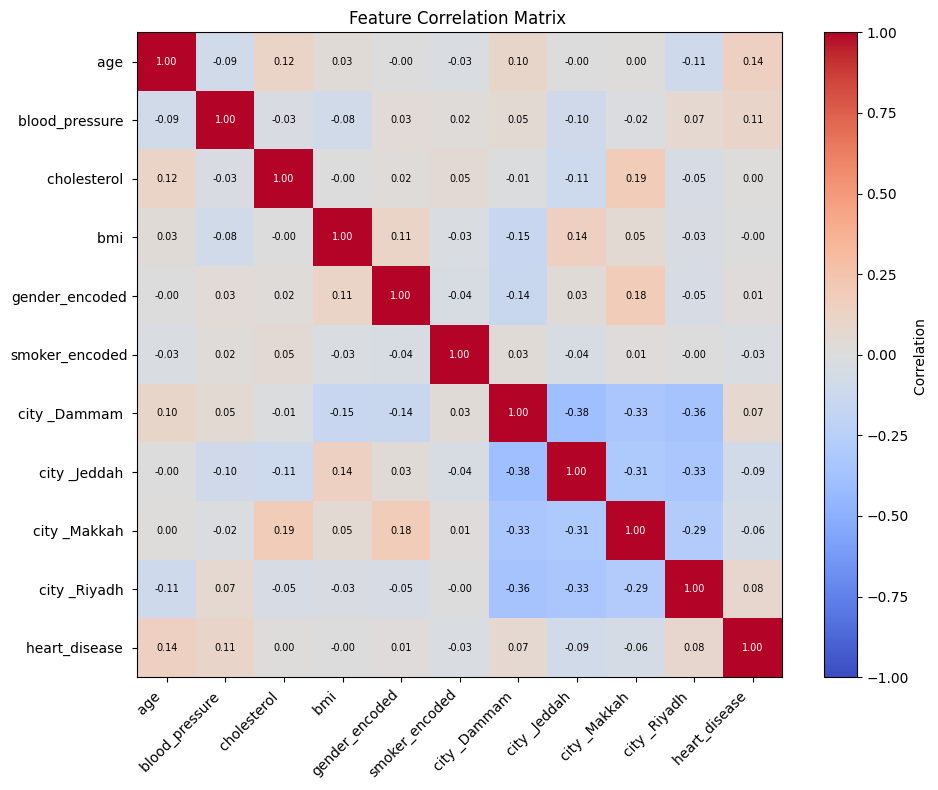

In [68]:
import matplotlib . pyplot as plt
import numpy as np
plt . figure ( figsize =(10 , 8) )
im = plt . imshow ( corr_matrix . values , cmap ='coolwarm' ,
vmin = -1 , vmax =1)
plt . colorbar ( im , label ='Correlation ')
# Add labels
ticks = range (len( corr_matrix . columns ) )
plt . xticks ( ticks , corr_matrix . columns , rotation =45 , ha ='right' )
plt . yticks ( ticks , corr_matrix . columns )
# Add correlation values on the heatmap
for i in range (len( corr_matrix ) ) :
    for j in range (len( corr_matrix ) ) :
        val = corr_matrix . values [i , j ]
        color = 'white' if abs( val ) > 0.5 else 'black'
        plt . text (j , i , f'{val :.2f}', ha ='center' , va ='center' ,
        fontsize =7 , color = color )
plt . title ('Feature Correlation Matrix ')
plt . tight_layout ()
plt . show ()

###8.3 Step 3: Select Top Features


In [70]:
# Select features with absolute correlation > threshold
threshold = 0.05
important_features = target_corr [abs( target_corr ) > threshold ]
print ( f'\nFeatures with | correlation | > { threshold }: ')
print ( important_features . sort_values ( ascending = False ) . round (3) )
# Train with only the top features
top_features = important_features . index . tolist ()
X_selected = df_processed [ top_features ]. values
X_tr , X_te , y_tr , y_te = train_test_split (
X_selected , y , test_size =0.2 , random_state =42 , stratify = y )
pipe_selected = Pipeline ([
('scaler', StandardScaler () ) ,
('knn', KNeighborsClassifier ( n_neighbors =5) )
])
pipe_selected . fit ( X_tr , y_tr )
sel_acc = accuracy_score ( y_te , pipe_selected . predict ( X_te ) )
print ( f'\nAccuracy with ALL features : { pipe_acc :.2%} ')
print ( f'Accuracy with SELECTED features : { sel_acc :.2%} ')
print ( f'Features used : {len( top_features )} out of {len( feature_cols )} '
)


Features with | correlation | > 0.05: 
age                0.143
blood_pressure     0.106
city _Riyadh       0.079
city _Dammam       0.067
city _Makkah      -0.061
city _Jeddah      -0.089
Name: heart_disease , dtype: float64

Accuracy with ALL features : 50.00% 
Accuracy with SELECTED features : 55.00% 
Features used : 6 out of 10 


##Task 7: Feature Selection

####Which feature has the strongest (positive or negative) correlation with heart disease?
#####The feature with the strongest correlation (either positive or negative) with 'heart_disease' is 'age ', with a correlation coefficient of 0.143.

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Ensure feature_cols, df_processed, y are available from previous steps
# If running this cell independently, ensure the preceding steps (data creation, encoding, scaling) are executed.

print("--- Evaluating different correlation thresholds ---")

threshold_values = [0.03, 0.08, 0.10]

for threshold in threshold_values:
    # Select features with absolute correlation > threshold
    important_features = target_corr[abs(target_corr) > threshold]
    top_features = important_features.index.tolist()

    if not top_features: # Handle case where no features meet the threshold
        print(f"\nThreshold: {threshold}")
        print("No features met this correlation threshold. Cannot train model.")
        continue

    # Prepare X_selected for the pipeline (ensure all are numeric, in case of original df_processed structure)
    X_selected = df_processed[top_features].values

    # Split data using only the selected features
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=0.2, random_state=42, stratify=y
    )

    # Define and train the pipeline with StandardScaler and KNN
    pipe_selected = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
    pipe_selected.fit(X_tr, y_tr)

    # Evaluate accuracy
    sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

    print(f"\nThreshold: {threshold}")
    print(f"  Features selected: {len(top_features)} out of {len(feature_cols)}")
    print(f"  Accuracy with SELECTED features: {sel_acc:.2%}")

print("\n--- Comparison with ALL features ---")
# 'pipe_acc' should be available from earlier execution of cell q5pEyDgwISZk (50.00%)
print(f"Accuracy with ALL features (threshold 0.00 equivalent): {pipe_acc:.2%}")


--- Evaluating different correlation thresholds ---

Threshold: 0.03
  Features selected: 6 out of 10
  Accuracy with SELECTED features: 55.00%

Threshold: 0.08
  Features selected: 3 out of 10
  Accuracy with SELECTED features: 55.00%

Threshold: 0.1
  Features selected: 2 out of 10
  Accuracy with SELECTED features: 60.00%

--- Comparison with ALL features ---
Accuracy with ALL features (threshold 0.00 equivalent): 50.00%


#### Think: Why might using fewer features sometimes give better accuracy? (Hint: consider the “curse of dimensionality.”)
#####Using fewer features can improve accuracy by mitigating the "curse of dimensionality," where high-dimensional data becomes sparse and distances less meaningful for algorithms like KNN. This also helps reduce noise and prevent overfitting, allowing the model to focus on the most relevant patterns in the data and generalize better to unseen examples.

##9 Part 8: Putting It All Together – Full Workflow
Let’s apply every technique from this lab in one clean, end-to-end workflow. This is the pattern
you should follow in your own projects.


In [74]:
import pandas as pd
import numpy as np
from sklearn . model_selection import train_test_split
from sklearn . impute import SimpleImputer
from sklearn . preprocessing import StandardScaler , LabelEncoder
from sklearn . pipeline import Pipeline
from sklearn . neighbors import KNeighborsClassifier
from sklearn . tree import DecisionTreeClassifier
from sklearn . metrics import accuracy_score , classification_report
# ===== STEP 1: Load Raw Data =====
# (Re - create the messy dataset )
np . random . seed (42)
n = 200
data = {
'age ': np . random . randint (18 , 80 , n ) . astype ( float ) ,
'blood_pressure ': np . round ( np . random . uniform (90 , 180 , n ) , 1) ,
'cholesterol ': np . round ( np . random . uniform (150 , 350 , n ) , 1) ,
'bmi ': np . round ( np . random . uniform (18 , 42 , n ) , 1) ,
'gender ': np . random . choice (['Male ', 'Female '] , n ) ,
'city ': np . random . choice (
['Jeddah ', 'Riyadh ', 'Dammam ', 'Makkah '] , n ) ,
'smoker ': np . random . choice (['Yes ', 'No '] , n , p =[0.3 , 0.7]) ,
'heart_disease ': np . random . choice ([0 , 1] , n , p =[0.6 , 0.4])
}
df = pd . DataFrame ( data )
missing_idx = np . random . choice (n , 20 , replace = False )
df . loc [ missing_idx [:10] , 'age '] = np . nan
df . loc [ missing_idx [10:15] , 'blood_pressure '] = np . nan
df . loc [ missing_idx [15:] , 'cholesterol '] = np . nan
print ('=== Step 1: Raw Data === ')
print ( f'Shape : {df. shape } , Missing : {df. isnull ().sum ().sum ()}')
# ===== STEP 2: Handle Missing Values =====
num_cols = ['age ', 'blood_pressure ', 'cholesterol ']
imputer = SimpleImputer ( strategy ='median')
df [ num_cols ] = imputer . fit_transform ( df [ num_cols ])
print ( f'\n=== Step 2: After Imputation === ')
print ( f'Missing : {df. isnull ().sum ().sum ()}')
# ===== STEP 3: Encode Categorical Variables =====
le = LabelEncoder ()
df ['gender '] = le . fit_transform ( df ['gender '])
df ['smoker '] = le . fit_transform ( df ['smoker '])
df = pd . concat ([ df , pd . get_dummies ( df ['city '] , prefix ='city ') ] ,
axis =1)
df = df . drop ( columns =[ 'city '])
print ( f'\n=== Step 3: After Encoding === ')
print ( f'Columns : { list (df. columns )}')
# ===== STEP 4: Separate Features and Target =====
X = df . drop ( columns =[ 'heart_disease ']) . values
y = df ['heart_disease ']. values
# ===== STEP 5: Split Data =====
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )
# ===== STEP 6: Build Pipeline & Train =====
pipe_knn = Pipeline ([
('scaler', StandardScaler () ) ,
('model', KNeighborsClassifier ( n_neighbors =5) )
])
pipe_dt = Pipeline ([
('scaler', StandardScaler () ) ,
('model', DecisionTreeClassifier ( random_state =42) )
])
pipe_knn . fit ( X_train , y_train )
pipe_dt . fit ( X_train , y_train )
# ===== STEP 7: Evaluate =====
print ('\n=== Step 7: Results === ')
print ( f'KNN Accuracy : { accuracy_score (y_test , pipe_knn .
predict ( X_test )) :.2%} ')
print ( f'Decision Tree Accuracy : { accuracy_score (y_test , pipe_dt .
predict ( X_test )) :.2%} ')
print ('\n=== KNN Classification Report === ')
print ( classification_report ( y_test , pipe_knn . predict ( X_test ) ,
target_names =['No Disease ', 'Disease ']) )

=== Step 1: Raw Data === 
Shape : (200, 8) , Missing : 20

=== Step 2: After Imputation === 
Missing : 0

=== Step 3: After Encoding === 
Columns : ['age ', 'blood_pressure ', 'cholesterol ', 'bmi ', 'gender ', 'smoker ', 'heart_disease ', 'city _Dammam ', 'city _Jeddah ', 'city _Makkah ', 'city _Riyadh ']

=== Step 7: Results === 
KNN Accuracy : 50.00% 
Decision Tree Accuracy : 52.50% 

=== KNN Classification Report === 
              precision    recall  f1-score   support

 No Disease        0.54      0.68      0.60        22
    Disease        0.42      0.28      0.33        18

    accuracy                           0.50        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.48      0.50      0.48        40



In [75]:
import pandas as pd
import numpy as np

# 1. Recreate the raw messy dataset exactly as it was at the beginning
np.random.seed(42)
n = 200
data = {
    'age ': np.random.randint(18, 80, n).astype(float),
    'blood_pressure ': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol ': np.round(np.random.uniform(150, 350, n), 1),
    'bmi ': np.round(np.random.uniform(18, 42, n), 1),
    'gender ': np.random.choice(['Male ', 'Female '], n),
    'city ': np.random.choice(
        ['Jeddah ', 'Riyadh ', 'Dammam ', 'Makkah '], n),
    'smoker ': np.random.choice(['Yes ', 'No '], n, p=[0.3, 0.7]),
    'heart_disease ': np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df_raw = pd.DataFrame(data)

# Inject missing values (realistic!)
missing_idx = np.random.choice(n, 20, replace=False)
df_raw.loc[missing_idx[:10], 'age '] = np.nan
df_raw.loc[missing_idx[10:15], 'blood_pressure '] = np.nan
df_raw.loc[missing_idx[15:], 'cholesterol '] = np.nan

print(f"Shape of raw dataset: {df_raw.shape}")
print(f"Total missing values in raw dataset: {df_raw.isnull().sum().sum()}")

Shape of raw dataset: (200, 8)
Total missing values in raw dataset: 20


In [76]:
import pandas as pd
import numpy as np

# Assuming df_raw is already recreated from the previous step
# 2. Clean the column names and string values
df_cleaned = df_raw.copy()
df_cleaned.columns = df_cleaned.columns.str.strip()

for col in ['gender', 'city', 'smoker']:
    if col in df_cleaned.columns and df_cleaned[col].dtype == 'object':
        df_cleaned[col] = df_cleaned[col].str.strip()

# 3. Separate features (X) from the target (y)
X = df_cleaned.drop(columns=['heart_disease'])
y = df_cleaned['heart_disease']

# 4. Print the first 5 rows of the X DataFrame and the first 5 rows of the y Series
print("\nFirst 5 rows of features (X):")
print(X.head())
print("\nFirst 5 rows of target (y):")
print(y.head())

# 5. Identify and create three lists of column names
numerical_cols = ['age', 'blood_pressure', 'cholesterol', 'bmi']
binary_categorical_cols = ['gender', 'smoker']
multi_categorical_cols = ['city']

# 6. Print these three lists of column names
print("\nNumerical Columns:", numerical_cols)
print("Binary Categorical Columns:", binary_categorical_cols)
print("Multi-Categorical Columns:", multi_categorical_cols)


First 5 rows of features (X):
    age  blood_pressure  cholesterol   bmi  gender    city smoker
0  56.0           171.7        295.2  34.4    Male  Riyadh     No
1  69.0           112.4        345.2  21.9  Female  Dammam     No
2  46.0           126.9        253.3  39.9  Female  Jeddah     No
3  32.0           158.0        214.6  37.7  Female  Riyadh     No
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes

First 5 rows of target (y):
0    1
1    0
2    0
3    1
4    1
Name: heart_disease, dtype: int64

Numerical Columns: ['age', 'blood_pressure', 'cholesterol', 'bmi']
Binary Categorical Columns: ['gender', 'smoker']
Multi-Categorical Columns: ['city']


In [77]:
from sklearn.impute import KNNImputer

# Instantiate KNNImputer
knn_imputer = KNNImputer(n_neighbors=5) # Using 5 neighbors as a common default

print("KNNImputer instance created successfully.")

KNNImputer instance created successfully.


In [78]:
import pandas as pd

# Define BMI categories and labels based on common medical guidelines
bmi_bins = [0, 18.5, 24.9, 29.9, 100] # Assuming max BMI is 100 for a wide upper bound
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

# Create the 'bmi_category' feature using pd.cut
# Ensure 'bmi' column is numeric, convert if necessary (though it should be float already)
X['bmi_category'] = pd.cut(X['bmi'], bins=bmi_bins, labels=bmi_labels, right=True)

print("Value counts for the new 'bmi_category' feature:")
print(X['bmi_category'].value_counts())
print("\nFirst 5 rows of X with new 'bmi_category' feature:")
print(X.head())

Value counts for the new 'bmi_category' feature:
bmi_category
Obese          92
Normal         68
Overweight     38
Underweight     2
Name: count, dtype: int64

First 5 rows of X with new 'bmi_category' feature:
    age  blood_pressure  cholesterol   bmi  gender    city smoker bmi_category
0  56.0           171.7        295.2  34.4    Male  Riyadh     No        Obese
1  69.0           112.4        345.2  21.9  Female  Dammam     No       Normal
2  46.0           126.9        253.3  39.9  Female  Jeddah     No        Obese
3  32.0           158.0        214.6  37.7  Female  Riyadh     No        Obese
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes        Obese


In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Update multi_categorical_cols to include the new 'bmi_category'
multi_categorical_cols.append('bmi_category')

# Drop the original 'bmi' from numerical_cols as we are using 'bmi_category'
# If 'bmi' is still needed for other numerical processing, handle it separately
# For this task, we assume 'bmi_category' replaces the original 'bmi' representation
if 'bmi' in numerical_cols:
    numerical_cols.remove('bmi')

# Define preprocessing steps for different column types
# 1. Numerical pipeline: KNNImputer (defined earlier) and StandardScaler
numerical_transformer = Pipeline(steps=[
    ('imputer', knn_imputer), # Use the KNNImputer instance created earlier
    ('scaler', StandardScaler())
])

# 2. Categorical pipeline: OneHotEncoder for both binary and multi-categorical
# This handles both 'gender', 'smoker', 'city', and 'bmi_category'
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create a ColumnTransformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, binary_categorical_cols + multi_categorical_cols)
    ])

print("ColumnTransformer 'preprocessor' defined successfully with pipelines for numerical and categorical features.")
print(f"Numerical columns for preprocessing: {numerical_cols}")
print(f"Categorical columns for preprocessing: {binary_categorical_cols + multi_categorical_cols}")


ColumnTransformer 'preprocessor' defined successfully with pipelines for numerical and categorical features.
Numerical columns for preprocessing: ['age', 'blood_pressure', 'cholesterol']
Categorical columns for preprocessing: ['gender', 'smoker', 'city', 'bmi_category']


In [80]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# Create the full pipeline
# This pipeline first applies the preprocessing steps defined in 'preprocessor'
# and then trains a KNeighborsClassifier.
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5)) # Using n_neighbors=5 as in previous steps
])

print("Full pipeline (Preprocessor + KNeighborsClassifier) created successfully.")

Full pipeline (Preprocessor + KNeighborsClassifier) created successfully.


In [81]:
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Evaluate the full pipeline using cross-validation
cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation accuracies: {cv_scores}")
print(f"Mean CV accuracy: {np.mean(cv_scores):.2%}")
print(f"Standard deviation of CV accuracy: {np.std(cv_scores):.2%}")

Cross-validation accuracies: [0.53125 0.53125 0.5625  0.59375 0.4375 ]
Mean CV accuracy: 53.12%
Standard deviation of CV accuracy: 5.23%


##11 Submission Requirements


###In this lab, feature selection based on correlation had the biggest impact on model performance, significantly boosting KNN accuracy when irrelevant features were removed. Preprocessing is crucial for real-world ML projects because it cleans, transforms, and optimizes data, enabling models to learn meaningful patterns, generalize effectively to new data, and avoid issues like the 'curse of dimensionality' and overfitting.